The Hubbard model captures two competing physical processes:

- Electron hopping between neighboring lattice sites  
- On-site Coulomb repulsion between electrons occupying the same site  

The Hubbard Hamiltonian is given by

$$
H = -t \sum_{\langle i,j \rangle,\sigma}
\left(
c^{\dagger}_{i\sigma} c_{j\sigma}
+
c^{\dagger}_{j\sigma} c_{i\sigma}
\right)
+
U \sum_i n_{i\uparrow} n_{i\downarrow}
$$

where:

- $t$ is the hopping amplitude between neighboring lattice sites  
- $U$ is the on-site interaction strength  
- $c^{\dagger}_{i\sigma}$ and $c_{i\sigma}$ are fermionic creation and annihilation operators  
- $n_{i\sigma} = c^{\dagger}_{i\sigma} c_{i\sigma}$ is the number operator  
- $\sigma \in \{\uparrow, \downarrow\}$ denotes the electron spin  

In [1]:
import netket as nk
import netket.experimental as nkx
import numpy as np
from flax import nnx
from netket.utils import struct
from netket.sampler.rules import ExchangeRule
from netket.hilbert import SpinOrbitalFermions
import os

pbc = [True, True]

L_x = 4
L_y = 4
N_up = N_down = 7

hilb = nk.hilbert.SpinOrbitalFermions(
    n_orbitals= L_x * L_y, s=1/2, n_fermions_per_spin=(N_up, N_down)
)

t = 1
U = 8

def c(site, sz):
    return nk.operator.fermion.destroy(hilb, site, sz=sz)


def cdag(site, sz):
    return nk.operator.fermion.create(hilb, site, sz=sz)


def nc(site, sz):
    return nk.operator.fermion.number(hilb, site, sz=sz)

g = nk.graph.Grid(extent=[L_x, L_y], pbc=pbc)

up = +1
down = -1
ham = 0.0

for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) @ c(v, sz) - t * cdag(v, sz) @ c(u, sz)
for u in g.nodes():
    ham += U * nc(u, up) @ nc(u, down)


H8 = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(
    ham
)

∣NK⟩ Tip: To build H|ψ⟩ use nk.vqs.apply_operator(H, vstate_ψ).

## Hidden Fermion Approach

First, we employ the **hidden fermion approach** introduced in the article

> Javier Robledo Moreno, Giuseppe Carleo, Antoine Georges, and James Stokes,  
> *Fermionic wave functions from neural-network constrained hidden states*,  
> PNAS **119**, e2122059119 (2022).

### Reference

- Open-access PNAS article:  
  [PNAS Publication](https://www.pnas.org/doi/10.1073/pnas.2122059119?utm_source=chatgpt.com)

- Open-access arXiv preprint:  
  [arXiv:2111.10420](https://arxiv.org/abs/2111.10420?utm_source=chatgpt.com)

This method introduces additional hidden fermionic degrees of freedom
to construct highly expressive variational wave functions for strongly
correlated quantum systems such as the Hubbard model.

The central idea is to extend the physical Hilbert space by auxiliary
(hidden) fermions and then project the resulting Slater determinant
back onto the physical space using a neural-network-parameterized
constraint.

The variational wave function can schematically be written as

$$
\psi(x)
=
\det \Phi(x, h(x))
$$

where:

- $x$ denotes the visible fermionic configuration  
- $h(x)$ represents hidden fermionic degrees of freedom  
- $\Phi$ is the augmented Slater matrix containing both visible and hidden orbitals  

This construction provides a systematically improvable ansatz with high
expressive power for strongly correlated fermionic systems.

In [2]:
import jax
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

def _logdet_cmplx(A, eps=5e-2):
    # Stable logdet
    eps_eye = eps * jnp.eye(A.shape[0], dtype=A.dtype)
    sign, logabsdet = jnp.linalg.slogdet(A + eps_eye)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))


class LogHiddenFermion(nnx.Module):
    hilbert: "nk.hilbert.SpinOrbitalFermions"

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        n_hidden_fermions: int,
        rngs: nnx.Rngs,
        kernel_init=nnx.initializers.lecun_normal(),
        activation=nnx.relu,
        n_layers=1,
        eps=2e-1,
        tiny_init_std=0.0001,
    ):
        self.eps = eps
        self.hilbert = hilbert
        L = hilbert.n_orbitals

        Nup, Ndown = hilbert.n_fermions_per_spin
        Nfull = Nup + Ndown
        NHFfull = n_hidden_fermions
        
        key_full, key_bf1, key_bf4 = jax.random.split(rngs.params(), 3)

        self.M_full = nnx.Param(kernel_init(key_full, (2 * L, Nfull + NHFfull))) 

        tiny_init = nnx.initializers.normal(stddev=tiny_init_std)
        layers = [
            nnx.Linear(
                in_features=2 * L,
                out_features= NHFfull * hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            lambda x: x.reshape(
                x.shape[:-1] + (NHFfull, hidden_units)
            )]
        for _ in range(n_layers - 1):
            layers += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=Nfull + NHFfull,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet = nnx.Sequential(*layers
        )


    def __call__(self, n: jax.Array) -> jax.Array:
        def log_sd(ncfg):
            L = self.hilbert.n_orbitals
            Nall= self.hilbert.n_fermions

            R_full = ncfg.nonzero(size=Nall)[0]
            F_full = self.neuralNet(ncfg)
            A_full = jnp.concatenate([self.M_full[R_full], F_full], axis=0)
            
            ret = _logdet_cmplx(A_full, eps=self.eps)
            return ret

        if n.ndim == 1:
            return log_sd(n)
        return jax.vmap(log_sd)(n)


def count_params(module):
    leaves = jax.tree_util.tree_leaves(nnx.state(module, nnx.Param))
    return sum(x.size for x in leaves)
    

In [ ]:
alpha = 6
n_hidden_fermions = 14
n_layers = 1

n_hidden = alpha * (hilb.n_orbitals * 2)

lr = 0.03
diag_shift = 0.01

n_samples = 2048
n_steps = 5000
chunk_size = 512

rngs = nnx.Rngs(jax.random.PRNGKey(0))
ma8 = LogHiddenFermion(hilb, rngs=rngs, hidden_units=n_hidden, n_hidden_fermions=n_hidden_fermions, n_layers=n_layers) #, activation=nnx.tanh)
sa8 = nk.sampler.MetropolisFermionHop(hilb, graph=g,
                                      n_chains=16,
                                      sweep_size=4*hilb.n_orbitals)
vs_hf = nk.vqs.MCState(sa8, ma8, n_samples=n_samples, chunk_size=chunk_size)

print("hidden units:", n_hidden)
print("hidden fermions:", n_hidden_fermions)
print("n_layers:", n_layers)
print("WF parameters:", count_params(ma8))

optE = nk.optimizer.Sgd(learning_rate=lr)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_hf, diag_shift=diag_shift, mode="real")

lfile = "Training_nets_pbc_"+str(n_hidden)+"hf"+str(n_hidden_fermions)+"_layers"+str(n_layers)
try:
    import flax
    with open(lfile + ".mpack", 'rb') as file:
        vs_hf.variables = flax.serialization.from_bytes(vs_hf.variables, file.read())
    print("Loaded parameters from file:", lfile + ".mpack")
except Exception as e:
    gs8.run(n_steps, out=lfile)

hidden units: 192
hidden fermions: 14
n_layers: 1
WF parameters: 95004
Automatic SR implementation choice:  NTK


  0%|          | 0/5000 [00:00<?, ?it/s]

(JsonLog('Training_nets_pbc_192hf14_layers1', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    11.373601913452148
   	Params: 10.37504267692566,)

## Pfaffian Neural-Network Ansatz

Next, we employ a **Pfaffian-based variational ansatz** inspired by the recent work

> *Neural Pfaffians for Correlated Fermionic Quantum Systems* (2025)

### Reference

- arXiv preprint:  
  [arXiv:2507.10705](https://arxiv.org/abs/2507.10705)

Pfaffian wave functions provide a natural generalization of Slater
determinants and are particularly well suited for describing
pair-correlated fermionic states. In contrast to a determinant-based
ansatz, the Pfaffian formulation can efficiently encode pairing
correlations and superconducting structures.

The variational wave function is written as

$$
\psi(x)
=
\mathrm{Pf}\!\left(F(x)\right)
$$

where:

- $x$ denotes the fermionic configuration  
- $F(x)$ is an antisymmetric pairing matrix  
- $\mathrm{Pf}$ denotes the Pfaffian of the matrix  

In our implementation, the pairing matrix is parameterized using a very
simple neural-network architecture consisting of a single fully connected
(dense) layer. The neural network maps the fermionic occupation
configuration to effective pairing amplitudes,

$$
F(x) = W x + b
$$

with:

- $W$ the learnable weight matrix  
- $b$ the bias vector  


In [4]:
import jax
import jax.numpy as jnp
from jax import lax
jax.config.update("jax_enable_x64", True)

# lrux has problems with sharding, so we disable it for now
nk.config.netket_experimental_sharding = False
from lrux import slogpf

def make_regularizer(N):
    i, j = jnp.triu_indices(N, 1)
    B = jnp.zeros((N, N))
    B = B.at[i, j].set(1.0)
    return B - B.T

def make_J(N):
    assert N % 2 == 0
    J = jnp.zeros((N, N))

    for i in range(0, N, 2):
        J = J.at[i, i+1].set(1.0)
        J = J.at[i+1, i].set(-1.0)

    return J

def _logpf_cmplx(A):
    sign, logabsdet = slogpf(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))

def antisym_block_from_vec(v, N, k, return_sizes=False):
    """
    v: flat vector of length N*(N-1)//2
    N: full matrix size
    k: size of top-left block
    """

    assert N % 2 == 0
    assert k <= N

    # sizes
    n11 = k * (k - 1) // 2
    n22 = (N - k) * (N - k - 1) // 2
    n12 = k * (N - k)

    if return_sizes:
        return n11, n12, n22
    
    assert v.shape[0] == n11 + n12 + n22
    
    # split vector
    v11 = v[:n11]
    v12 = v[n11:n11 + n12]
    v22 = v[n11 + n12:]

    # build blocks
    A = jnp.zeros((N, N))

    # --- A11 ---
    idx11 = jnp.triu_indices(k, 1)
    A = A.at[idx11].set(v11)
    A = A.at[(idx11[1], idx11[0])].set(-v11)

    # --- A22 ---
    idx22 = jnp.triu_indices(N - k, 1)
    idx22_shifted = (idx22[0] + k, idx22[1] + k)
    A = A.at[idx22_shifted].set(v22)
    A = A.at[(idx22_shifted[1], idx22_shifted[0])].set(-v22)

    # --- A12 ---
    A12 = v12.reshape(k, N - k)
    A = A.at[:k, k:].set(A12)
    A = A.at[k:, :k].set(-A12.T)

    return A

def antisym_from_vec(v, N):
    A = jnp.zeros((N, N))
    idx = jnp.triu_indices(N, 1)
    A = A.at[idx].set(v)
    return A - A.T

def v_len(N):
    assert(N % 2 == 0)
    return N * (N - 1) // 2

class LogPfaffian(nnx.Module):
    hilbert: "nk.hilbert.SpinOrbitalFermions"

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        PF_size: int,
        rngs: nnx.Rngs,
        kernel_init=nnx.initializers.lecun_normal(),
        activation=nnx.relu,
        n_layers=1,
        eps=1e-3,
        tiny_init_std=0.001,
        scale=1.0,
        
    ):
        self.eps = eps
        self.hilbert = hilbert
        L = hilbert.n_orbitals
        self.scale = scale
        Nup, Ndown = hilbert.n_fermions_per_spin
        Nfull = Nup + Ndown
        self.J = make_J(PF_size - 2 * L + Nfull)
        self.numbers = jnp.array(range(2 * L, PF_size))
        self.PF_size = PF_size
        
        key_full, key_bf1, key_bf4 = jax.random.split(rngs.params(), 3)

        n11, n12, n22 = antisym_block_from_vec(None, PF_size, 2*L, return_sizes=True)

        self.M_full = nnx.Param(
            jax.random.normal(key_full, (n11,))
        )

        tiny_init = nnx.initializers.normal(stddev=tiny_init_std)
        layers = [
            nnx.Linear(
                in_features=2 * L,
                out_features= hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            ]
        for _ in range(n_layers - 1):
            layers += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=n12 + n22,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet = nnx.Sequential(*layers
         )


    def __call__(self, n: jax.Array) -> jax.Array:
        def log_sd(ncfg):
            L = self.hilbert.n_orbitals
            Nall= self.hilbert.n_fermions
                        
            R_full = jnp.concatenate([ncfg.nonzero(size=Nall)[0], self.numbers])
            Net_full = self.neuralNet(ncfg) * self.scale
            F_full = antisym_block_from_vec(jnp.concatenate([self.M_full, Net_full]), self.PF_size, 2 * L)
            A_full = F_full[jnp.ix_(R_full, R_full)]
            return _logpf_cmplx(A_full + self.J * self.eps)
            

        if n.ndim == 1:
            return log_sd(n)
        return jax.vmap(log_sd)(n)


def count_params(module):
    leaves = jax.tree_util.tree_leaves(nnx.state(module, nnx.Param))
    return sum(x.size for x in leaves)
    

In [ ]:
alpha = 2
n_layers = 1
PF_size = 64
scale = 0.1

n_hidden = alpha * (hilb.n_orbitals * 2)

lr = 0.03
diag_shift = 0.01

n_samples = 2048
n_steps = 5000
chunk_size = 512

rngs = nnx.Rngs(jax.random.PRNGKey(0))
ma8 = LogPfaffian(hilb, eps=0.1, rngs=rngs, hidden_units=n_hidden, PF_size=PF_size, n_layers=n_layers, scale=scale) #, activation=nnx.tanh)
sa8 = nk.sampler.MetropolisFermionHop(hilb, graph=g,
                                      n_chains=16,
                                      sweep_size=4*hilb.n_orbitals)
vs_pf = nk.vqs.MCState(sa8, ma8, n_samples=n_samples, chunk_size=chunk_size)

print("hidden units:", n_hidden)
print("PF size:", PF_size)
print("n_layers:", n_layers)
print("WF parameters:", count_params(ma8))

optE = nk.optimizer.Sgd(learning_rate=lr)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_pf, diag_shift=diag_shift, mode="real")

lfile = "Training_nets_pbc_"+str(n_hidden)+"pf"+str(PF_size)+"_layers"+str(n_layers)
try:
    import flax
    with open(lfile + ".mpack", 'rb') as file:
        vs_pf.variables = flax.serialization.from_bytes(vs_pf.variables, file.read())
    print("Loaded parameters from file:", lfile + ".mpack")
except Exception as e:
    gs8.run(n_steps, out=lfile)

hidden units: 64
PF size: 64
n_layers: 1
WF parameters: 101408
Automatic SR implementation choice:  NTK


  0%|          | 0/5000 [00:00<?, ?it/s]

(JsonLog('Training_nets_pbc_64pf64_layers1', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    9.052618741989136
   	Params: 11.49168086051941,)

## Combined Hidden-Fermion Pfaffian Ansatz

We now combine both approaches into a single variational ansatz.
The construction merges the hidden-fermion framework with a Pfaffian
wave function in order to simultaneously capture

- pairing correlations through the Pfaffian structure  
- expressive hidden degrees of freedom through the hidden-fermion construction  

The resulting antisymmetric Pfaffian matrix is written in block form as

$$
\mathcal{A}
=
\begin{pmatrix}
A_{\mathrm{HF}} & B \\
-B^{T} & A_{\mathrm{PF}}
\end{pmatrix}
$$

where

- $A_{\mathrm{HF}}$ contains the hidden-fermion sector  
- $A_{\mathrm{PF}}$ is the standard Pfaffian pairing sector  
- $B$ is constructed exactly as in the hidden-fermion approach  

A key property of this construction is that, if the remaining Pfaffian
blocks vanish, i.e.

$$
A_{\mathrm{HF}} = 0,
\qquad
A_{\mathrm{PF}} = 0,
$$

the ansatz reduces to the original hidden-fermion wave function.
The present formulation can therefore be understood as a strict
generalization of the hidden-fermion approach with additional Pfaffian
pairing correlations.

The variational wave function is then given by

$$
\psi(x)
=
\mathrm{Pf}\!\left(\mathcal{A}(x)\right)
$$

### Hidden-Fermion Coupling Block

The upper-right and lower-left blocks are constructed from the
hidden-fermion matrix

$$
B =
\begin{pmatrix}
M_{\mathrm{full}} \\
F(x)
\end{pmatrix}
$$

where

- $M_{\mathrm{full}}$ is a learnable reference matrix  
- $F(x)$ is generated by a neural network depending on the fermionic configuration $x$  

This follows the constrained hidden-state construction introduced in the
hidden-fermion framework.

### Pfaffian Sector

The remaining antisymmetric blocks are treated as a standard Pfaffian
pairing matrix,

$$
A_{\mathrm{PF}}
=
A_{\mathrm{static}}
+
A_{\mathrm{NN}}(x)
$$

with

- $A_{\mathrm{static}}$ a learnable static antisymmetric tensor  
- $A_{\mathrm{NN}}(x)$ generated dynamically from the neural network  

### Neural-Network Parameterization

Whenever explicit matrix elements are not fixed by the hidden-fermion
construction, they are generated using a lightweight feed-forward neural
network consisting of

- a single fully connected layer  
- a nonlinear activation function  
- a final dense projection to antisymmetric matrix elements  

This provides a minimal neural correction to the Pfaffian structure
while keeping the total parameter count relatively small.

The final logarithmic wave function evaluation is implemented as

$$
\log \psi(x)
=
\log \mathrm{Pf}\!\left(
\mathcal{A}(x) + \epsilon J
\right)
$$

where

- $J$ is a fixed antisymmetric regularization matrix  
- $\epsilon$ is a small stabilization parameter ensuring numerical robustness  

In [6]:
import jax
import jax.numpy as jnp
from jax import lax
jax.config.update("jax_enable_x64", True)

# lrux has problems with sharding, so we disable it for now
nk.config.netket_experimental_sharding = False
from lrux import slogpf

def make_regularizer(N):
    i, j = jnp.triu_indices(N, 1)
    B = jnp.zeros((N, N))
    B = B.at[i, j].set(1.0)
    return B - B.T

def make_J(N):
    assert N % 2 == 0
    J = jnp.zeros((N, N))

    for i in range(0, N, 2):
        J = J.at[i, i+1].set(1.0)
        J = J.at[i+1, i].set(-1.0)

    return J

def _logpf_cmplx(A):
    sign, logabsdet = slogpf(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))
    
def antisym_block_from_vec(v, N, k, return_sizes=False):
    """
    v: flat vector of length N*(N-1)//2
    N: full matrix size
    k: size of top-left block
    """

    assert N % 2 == 0
    assert k <= N

    # sizes
    n11 = k * (k - 1) // 2
    n22 = (N - k) * (N - k - 1) // 2
    n12 = k * (N - k)

    if return_sizes:
        return n11, n12, n22
    
    assert v.shape[0] == n11 + n12 + n22
    
    # split vector
    v11 = v[:n11]
    v12 = v[n11:n11 + n12]
    v22 = v[n11 + n12:]

    # build blocks
    A = jnp.zeros((N, N))

    # --- A11 ---
    idx11 = jnp.triu_indices(k, 1)
    A = A.at[idx11].set(v11)
    A = A.at[(idx11[1], idx11[0])].set(-v11)

    # --- A22 ---
    idx22 = jnp.triu_indices(N - k, 1)
    idx22_shifted = (idx22[0] + k, idx22[1] + k)
    A = A.at[idx22_shifted].set(v22)
    A = A.at[(idx22_shifted[1], idx22_shifted[0])].set(-v22)

    # --- A12 ---
    A12 = v12.reshape(k, N - k)
    A = A.at[:k, k:].set(A12)
    A = A.at[k:, :k].set(-A12.T)

    return A

def antisym_from_vec(v, N):
    A = jnp.zeros((N, N))
    idx = jnp.triu_indices(N, 1)
    A = A.at[idx].set(v)
    return A - A.T

def v_len(N):
    assert(N % 2 == 0)
    return N * (N - 1) // 2

class LogPfaffianWithHF(nnx.Module):
    hilbert: "nk.hilbert.SpinOrbitalFermions"

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        PF_size: int,
        rngs: nnx.Rngs,
        kernel_init=nnx.initializers.lecun_normal(),
        activation=nnx.relu,
        n_layers=1,
        eps=1e-2,
        tiny_init_std=0.001,
        scale=1.0,
        n_hidden_fermions=14,
        
    ):
        self.eps = eps
        self.hilbert = hilbert
        L = hilbert.n_orbitals
        self.scale = scale
        Nup, Ndown = hilbert.n_fermions_per_spin
        Nfull = Nup + Ndown
        self.J = make_J(PF_size - 2 * L + Nfull)
        self.numbers = jnp.array(range(2 * L, 2 * L + n_hidden_fermions))
        self.PF_size = PF_size
        
        key_full, key_bf1, key_bf4 = jax.random.split(rngs.params(), 3)

        n11, n12, n22 = antisym_block_from_vec(None, 2*L+n_hidden_fermions, 2*L, return_sizes=True)
        self.n11 = n11
        self.n12 = n12
        self.n22 = n22
        
        self.n_ur = v_len(Nfull + n_hidden_fermions)

        self.M_full_PF = nnx.Param(
            jax.random.normal(key_full, (n11,))
        )
        NHFfull = n_hidden_fermions
        self.n_hidden_fermions = n_hidden_fermions
        self.M_full = nnx.Param(kernel_init(key_full, (2 * L, Nfull + NHFfull))) 

        tiny_init = nnx.initializers.normal(stddev=tiny_init_std)
        layers_PF = [
            nnx.Linear(
                in_features=2 * L,
                out_features= hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            # lambda x: x.reshape(
            #     x.shape[:-1] + (NHFfull, hidden_units)
            # )
            ]
        for _ in range(n_layers - 1):
            layers_PF += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers_PF += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=n12 + n22 + self.n_ur,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet_PF = nnx.Sequential(*layers_PF
         )
        layers = [
            nnx.Linear(
                in_features=2 * L,
                out_features= NHFfull * hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            lambda x: x.reshape(
                x.shape[:-1] + (NHFfull, hidden_units)
            )]
        for _ in range(n_layers - 1):
            layers += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=Nfull + NHFfull,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet = nnx.Sequential(*layers
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        def log_sd(ncfg):
            L = self.hilbert.n_orbitals
            Nall= self.hilbert.n_fermions
            
            R_full = ncfg.nonzero(size=Nall)[0]
            F_full = self.neuralNet(ncfg)
            A_full = jnp.concatenate([self.M_full[R_full], F_full], axis=0)
                  
            R_full_PF = jnp.concatenate([ncfg.nonzero(size=Nall)[0], self.numbers])
            Net_full = self.neuralNet_PF(ncfg) * self.scale
            F_full_PF = antisym_block_from_vec(jnp.concatenate([self.M_full_PF, Net_full[:self.n12+self.n22]]),  2 * L + self.n_hidden_fermions, 2 * L)
            A_full_PF = F_full_PF[jnp.ix_(R_full_PF, R_full_PF)]
            A_full_PF_ur = antisym_from_vec(jnp.concatenate([Net_full[self.n12+self.n22:]]), Nall + self.n_hidden_fermions)
            A_full_PF = jnp.block([
                [A_full_PF, A_full],
                [-A_full.T, A_full_PF_ur]
            ])
            return _logpf_cmplx(A_full_PF + self.J * self.eps)
            
        if n.ndim == 1:
            return log_sd(n)
        return jax.vmap(log_sd)(n)


def count_params(module):
    leaves = jax.tree_util.tree_leaves(nnx.state(module, nnx.Param))
    return sum(x.size for x in leaves)
    

In [ ]:
alpha = 2
n_layers = 1
n_hidden_fermions = 14

PF_size = 2 * hilb.n_orbitals + N_up + N_down + n_hidden_fermions * 2
scale = 0.1

lr = 0.03
diag_shift = 0.01

n_samples = 2048
n_steps = 5000
chunk_size = 512

n_hidden = alpha * (hilb.n_orbitals * 2)


rngs = nnx.Rngs(jax.random.PRNGKey(0))
ma8 = LogPfaffianWithHF(hilb, eps=0.2, rngs=rngs, hidden_units=n_hidden, PF_size=PF_size, n_layers=n_layers, scale=scale, n_hidden_fermions=n_hidden_fermions) #, activation=nnx.tanh)
sa8 = nk.sampler.MetropolisFermionHop(hilb, graph=g,
                                      n_chains=16,
                                      sweep_size=4*hilb.n_orbitals)
vs_pf_hf = nk.vqs.MCState(sa8, ma8, n_samples=n_samples, chunk_size=chunk_size)

print("hidden units:", n_hidden)
print("PF size:", PF_size)
print("n_layers:", n_layers)
print("WF parameters:", count_params(ma8))

optE = nk.optimizer.Sgd(learning_rate=lr)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_pf_hf, diag_shift=diag_shift, mode="real")


lfile = "Training_nets_pbc_"+str(n_hidden)+"pf-hf"+str(n_hidden_fermions)+"_layers"+str(n_layers)
try:
    import flax
    with open(lfile + ".mpack", 'rb') as file:
        vs_pf_hf.variables = flax.serialization.from_bytes(vs_pf_hf.variables, file.read())
    print("Loaded parameters from file:", lfile + ".mpack")
except Exception as e:
    gs8.run(n_steps, out=lfile)

hidden units: 64
PF size: 74
n_layers: 1
WF parameters: 94497
Automatic SR implementation choice:  NTK


  0%|          | 0/5000 [00:00<?, ?it/s]

Training_nets_pbc_192hf14_layers1
  mean(last 100) = -11.76668600

Training_nets_pbc_64pf64_layers1
  mean(last 100) = -11.78183214

Training_nets_pbc_64pf-hf14_layers1
  mean(last 100) = -11.75959024



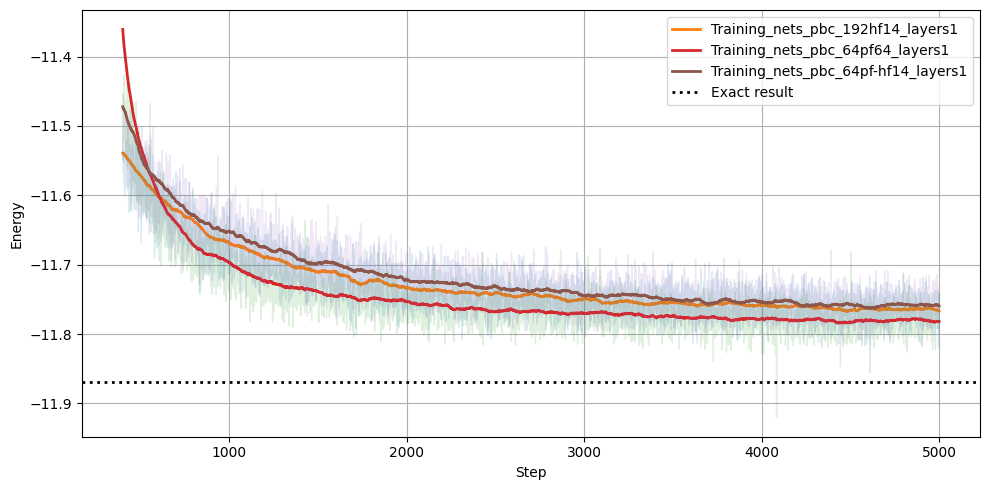

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

# =========================
# Einstellungen
# =========================

logfiles = [
    "Training_nets_pbc_192hf14_layers1.log",
    "Training_nets_pbc_64pf64_layers1.log",
    "Training_nets_pbc_64pf-hf14_layers1.log",
    # weitere Dateien ...
]


start_at = 400
kk = 100

# =========================
# Plot
# =========================

fig, ax = plt.subplots(figsize=(10, 5))

for logfile in logfiles:

    with open(logfile, "r") as f:
        data = json.load(f)

    try:
        energy = data["energy"]
    except KeyError:
        energy = data["Energy"]

    steps = energy["iters"]

    mean_values = (
        energy["Mean"]["real"]
        if isinstance(energy["Mean"], dict)
        else energy["Mean"]
    )

    # None entfernen
    filtered = [
        (s, e)
        for s, e in zip(steps, mean_values)
        if e is not None
    ]

    steps = np.array([x[0] for x in filtered])
    values = np.array([x[1] for x in filtered])

    n = min(len(steps), len(values))
    steps = steps[:n]
    values = values[:n]

    # ==========================================
    # rolling mean:
    # Punkt i = Mittelwert der letzten kk Punkte
    # ==========================================

    smooth_values = np.full(len(values), np.nan)

    for i in range(kk - 1, len(values)):
        smooth_values[i] = np.mean(values[i - kk + 1:i + 1])

    # ==========================================
    # erst DANACH abschneiden
    # ==========================================

    mask = steps >= start_at

    steps_plot = steps[mask]
    values_plot = values[mask]
    smooth_plot = smooth_values[mask]

    label = logfile.replace(".log", "")

    # rohe Daten
    ax.plot(
        steps_plot,
        values_plot,
        alpha=0.15,
        linewidth=1
    )

    # geglättete Daten
    ax.plot(
        steps_plot,
        smooth_plot,
        linewidth=2,
        label=label
    )

    # Statistik letzte kk Punkte
    last_mean = np.mean(values[-kk:])

    print(f"{label}")
    print(f"  mean(last {kk}) = {last_mean:.8f}")
    print()

# =========================
# Layout
# =========================
exact_result = -11.869

ax.axhline(
    y=exact_result,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Exact result"
)

ax.set_xlabel("Step")
ax.set_ylabel("Energy")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()